# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 10</span>

### Exercise 10.1

Choose **ONLY ONE** of the two following possibilities:

1. Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

2. Starting from your Genetic Algorithm code implement a **Parallel Tempering algorithm** (Simulated Annealing with many temperatures). Parallelize with MPI libraries your algorithm in order to solve the TSP where each computing node, up to 11, is characterized by a different temperature or a limited set of temperatures (if you need more than 11 temperatures). Use your genetic operators (except crossover) as trial moves for the Metropolis algorithm and **add a trial move that proposes an exchange of paths among adjacent temperatures (nodes)** (see lecture 8 for the acceptance formula). The candidate solution of the TSP will appear on the node with the lowest temperature.

### Exercise 10.2

Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.

If your choice in Exercise 10.1 is option 1, do you improve with respect using the same number of computing cores but with **independent GA searches** ?

If your choice in Exercise 10.1 is option 2, by using a number of temperatures equal to the number of individuals in your **non-parallel Genetic Algorithm code**, do you "improve" with respect to it?

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import cartopy.feature as cfeature


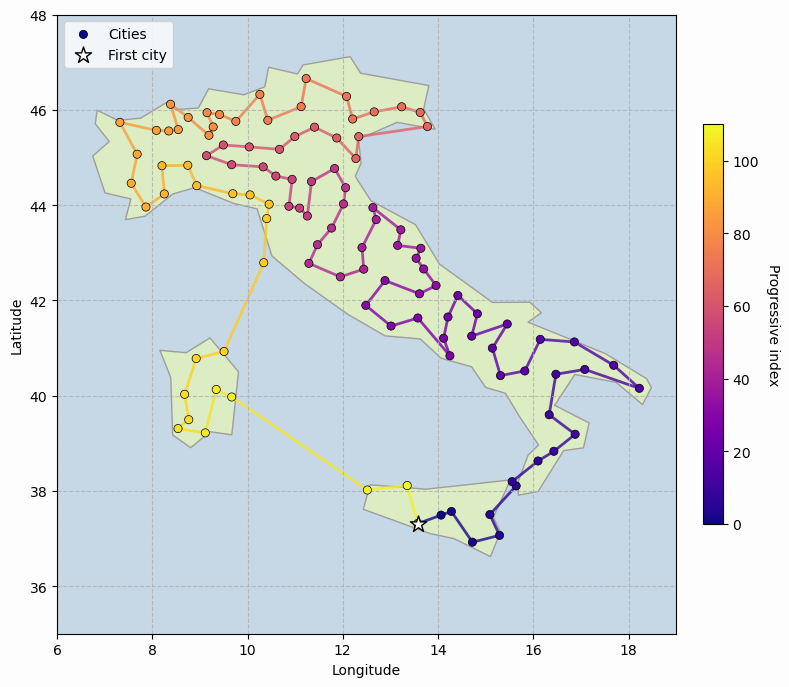

In [27]:
def plot_tsp_italy_with_borders(filename):
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    
    try:
        world = gpd.read_file(url)
        italy = world[world['NAME'] == "Italy"]
    except Exception as e:
        print(f"Errore nel caricamento della mappa: {e}")
        return

    data = np.loadtxt(filename)
    lon = data[:, 0]
    lat = data[:, 1]
    num_points = len(lon)

    fig, ax = plt.subplots(figsize=(8, 10), facecolor='#fdfdfd')
    ax.set_facecolor("#c6d7e6") 
    italy.plot(ax=ax, color="#dcecc3", edgecolor='#9e9e9e', linewidth=1, zorder=0)

    for i in range(num_points - 1):
        color = plt.cm.plasma(i / num_points)
        ax.plot(lon[i:i+2], lat[i:i+2], color=color, lw=2, zorder=1, alpha=0.8)

    sc = ax.scatter(lon, lat, 
                    c=np.arange(num_points), 
                    cmap='plasma', 
                    s=35, 
                    edgecolors='black', 
                    linewidths=0.5, 
                    zorder=2, 
                    label='Cities')

    ax.scatter(lon[0], lat[0], c='white', s=150, edgecolors='black', 
                marker='*', zorder=3, label='First city')

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Progressive index', rotation=270, labelpad=15)

    ax.set_xlim([6, 19])
    ax.set_ylim([35, 48])
    
    ax.set_aspect('equal')
    plt.grid(True, linestyle='--', alpha=0.8)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_tsp_italy_with_borders("italy_best_path_rank0.dat")

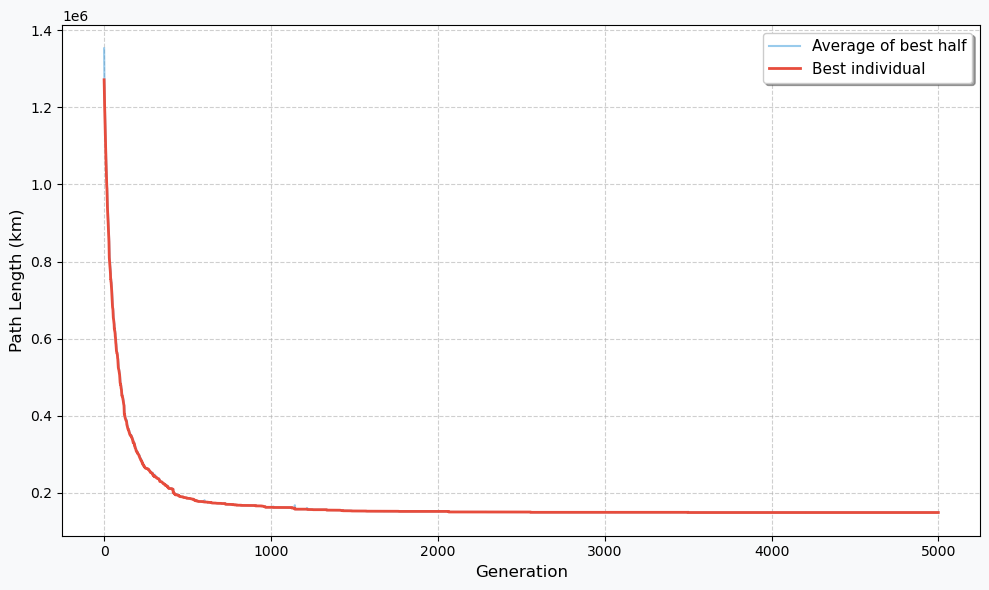

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_losses(filename):
    try:
        data = np.loadtxt(filename)
    except Exception as e:
        print(f"Errore nel caricamento del file {filename}: {e}")
        return

    gen = data[:, 0]
    best_loss = data[:, 1]
    ave_loss = data[:, 2]

    plt.figure(figsize=(10, 6), facecolor='#f8f9fa')
    
    plt.plot(gen, ave_loss, color='#3498db', alpha=0.5, label='Average of best half')
    plt.plot(gen, best_loss, color='#e74c3c', linewidth=2, label='Best individual')
    plt.xlabel("Generation", fontsize=12)
    plt.ylabel("Path Length (km)", fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_losses("3d/world_losses.dat")

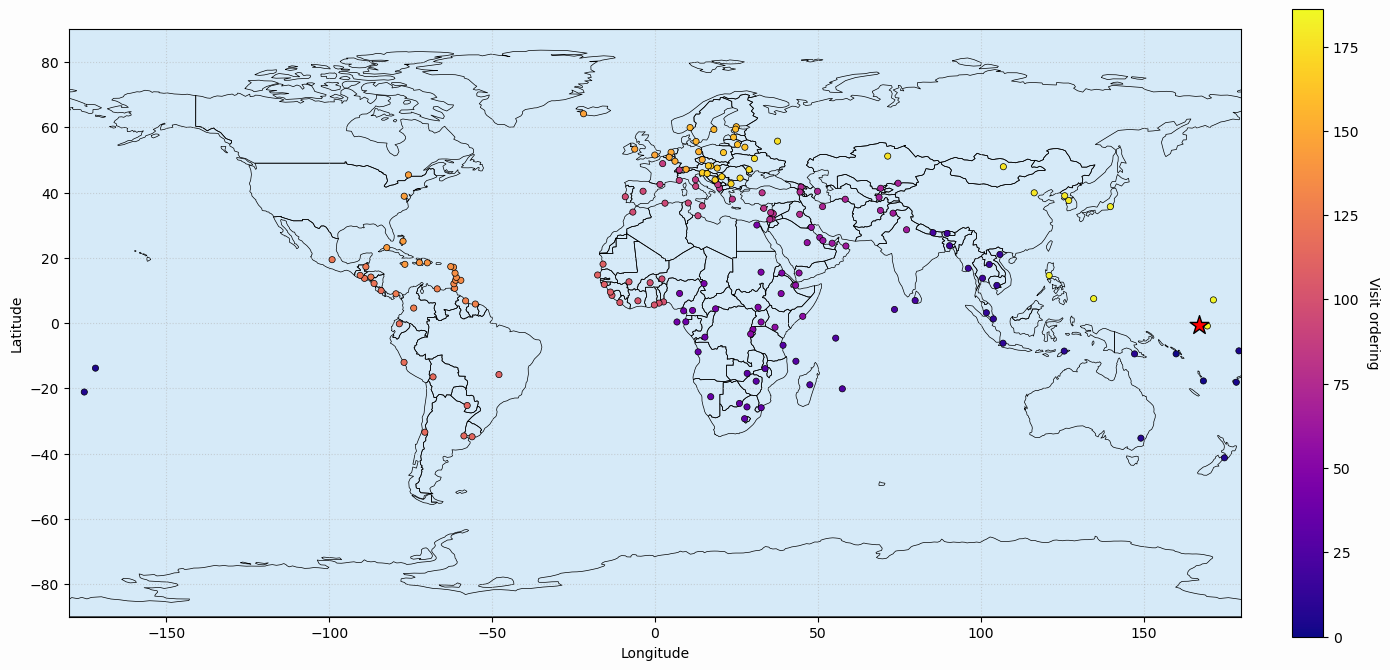

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os

def plot_2d_world_tsp_with_borders(filename):
    # Dataset Natural Earth (confini globali)
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

    try:
        world = gpd.read_file(url)
    except Exception as e:
        print(f"Errore nel caricamento della mappa: {e}")
        return

    # Caricamento dati (lat, lon)
    data = np.loadtxt(filename)
    lat = data[:, 0]
    lon = data[:, 1]
    num_points = len(lon)

    fig, ax = plt.subplots(figsize=(14, 7), facecolor='#fdfdfd')
    ax.set_facecolor("#d6eaf8")  # oceano

    world.boundary.plot(
        ax=ax,
        linewidth=0.5,
        color="black",
        zorder=1
    )

    for i in range(num_points - 1):
        x1, x2 = lon[i], lon[i+1]
        y1, y2 = lat[i], lat[i+1]

    sc = ax.scatter(
        lon, lat,
        c=np.arange(num_points),
        cmap='plasma',
        s=20,
        edgecolors='black',
        linewidths=0.5,
        zorder=3
    )

    ax.scatter(
        lon[0], lat[0],
        color='red',
        marker='*',
        s=200,
        edgecolors='black',
        zorder=4,
        label='Start'
    )
    ax.set_xlim([-180, 180])
    ax.set_ylim([-90, 90])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = plt.colorbar(sc, ax=ax, fraction=0.025, pad=0.04)
    cbar.set_label('Visit ordering', rotation=270, labelpad=15)

    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    plot_2d_world_tsp_with_borders("3d/world_best_path_rank0.dat")

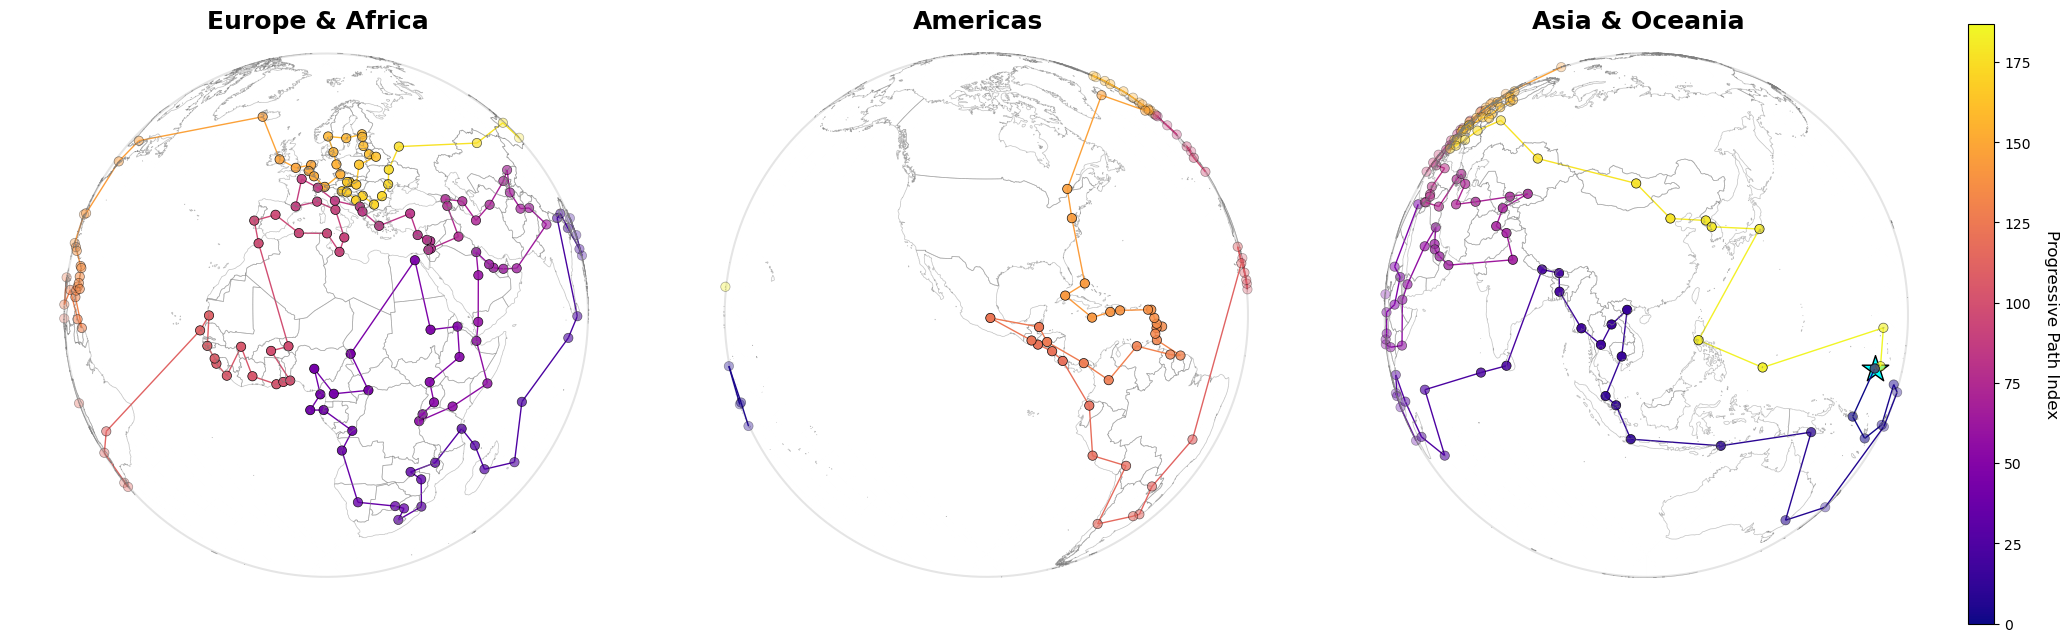

In [48]:
filename = "3d/world_best_path_rank0.dat"
try:
    data = np.loadtxt(filename)
    lat_rad = np.radians(data[:, 0])
    lon_rad = np.radians(data[:, 1])
    
    points_all = np.vstack((
        np.cos(lat_rad) * np.cos(lon_rad),
        np.cos(lat_rad) * np.sin(lon_rad),
        np.sin(lat_rad)
    )).T
    num_points = len(points_all)
except Exception as e:
    print(f"Errore caricamento file: {e}")
    exit()

shapefile = cfeature.NaturalEarthFeature('cultural', 'admin_0_countries', '50m')
geometries = list(shapefile.geometries())

views = [
    ("Europe & Africa", 20, 10),
    ("Americas", 20, -100),
    ("Asia & Oceania", 20, 110)
]

fig = plt.figure(figsize=(22, 10), facecolor='white')

for i, (title, elev, azim) in enumerate(views):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Zoom e orientamento
    ax.dist = 7.5 
    phi_cam = np.radians(elev)
    theta_cam = np.radians(azim)
    camera_vec = np.array([np.cos(phi_cam) * np.cos(theta_cam), 
                           np.cos(phi_cam) * np.sin(theta_cam), 
                           np.sin(phi_cam)])

    # --- NOVITÀ: DISEGNO BORDO ESTERNO (SILHOUETTE) ---
    # Creiamo un cerchio unitario sul piano perpendicolare a camera_vec
    t = np.linspace(0, 2*np.pi, 200)
    # Calcoliamo due vettori ortogonali a camera_vec per costruire la base del cerchio
    if abs(camera_vec[2]) < 0.9: # Se non stiamo guardando esattamente i poli
        v1 = np.cross(camera_vec, [0, 0, 1])
    else:
        v1 = np.cross(camera_vec, [0, 1, 0])
    v1 /= np.linalg.norm(v1)
    v2 = np.cross(camera_vec, v1)
    v2 /= np.linalg.norm(v2)
    
    # Generazione punti della circonferenza
    rim_points = np.array([np.cos(ti)*v1 + np.sin(ti)*v2 for ti in t])
    ax.plot(rim_points[:,0], rim_points[:,1], rim_points[:,2], color='black', linewidth=1.5, zorder=2, alpha=0.1)

    # --- DISEGNO MAPPA MONDIALE CON CULLING ---
    world_segments = []
    for geometry in geometries:
        parts = geometry.boundary.geoms if hasattr(geometry.boundary, 'geoms') else [geometry.boundary]
        for line in parts:
            coords = np.array(line.coords)
            if len(coords) < 2: continue
            l_lon, l_lat = coords[:, 0], coords[:, 1]
            x_w = np.cos(np.radians(l_lat)) * np.cos(np.radians(l_lon))
            y_w = np.cos(np.radians(l_lat)) * np.sin(np.radians(l_lon))
            z_w = np.sin(np.radians(l_lat))
            w_points = np.vstack((x_w, y_w, z_w)).T
            segs = np.concatenate([w_points[:-1, np.newaxis, :], w_points[1:, np.newaxis, :]], axis=1)
            mid_p = (w_points[:-1] + w_points[1:]) / 2.0
            visibility = np.dot(mid_p, camera_vec) > 1e-2
            world_segments.extend(segs[visibility])

    if world_segments:
        lc_map = Line3DCollection(world_segments, colors='gray', linewidths=0.5, alpha=0.5, zorder=1)
        ax.add_collection3d(lc_map)

    # --- DISEGNO PERCORSO (PATH) ---
    visible_mask = np.dot(points_all, camera_vec) > 1e-3
    if len(points_all) > 1:
        path_segs = np.concatenate([points_all[:-1, np.newaxis, :], points_all[1:, np.newaxis, :]], axis=1)
        path_vis = visible_mask[:-1] & visible_mask[1:]
        path_colors = plt.cm.plasma(np.linspace(0, 1, len(path_segs)))
        lc_path = Line3DCollection(path_segs[path_vis], colors=path_colors[path_vis], linewidths=1.0, zorder=5)
        ax.add_collection3d(lc_path)

    sc = ax.scatter(points_all[visible_mask, 0], points_all[visible_mask, 1], points_all[visible_mask, 2], 
                    c=np.where(visible_mask)[0], cmap='plasma', s=45, edgecolors='black', 
                    linewidths=0.5, zorder=10, vmin=0, vmax=num_points)

    if visible_mask[0]:
        ax.scatter(points_all[0,0], points_all[0,1], points_all[0,2], 
                   color='cyan', marker='*', s=400, edgecolors='black', zorder=20)

    # Estetica e Limiti (Zoom)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=18, fontweight='bold', y=1.05)
    ax.set_axis_off()
    
    limit = 0.7 
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect([1,1,1])
    
    # Sfera di riferimento quasi invisibile
    u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
    ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), 
                      color="lightgray", alpha=0.01, linewidth=0.1)

    # Posizionamento manuale per massimizzare la dimensione
    ax.set_position([0.05 + i*0.3, 0.05, 0.28, 0.9]) 

# 5. Colorbar e Layout finale
cbar_ax = fig.add_axes([0.94, 0.2, 0.012, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Progressive Path Index', rotation=270, labelpad=20, fontsize=12)

plt.show()